# Imports

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

# Exercise 7 part 1

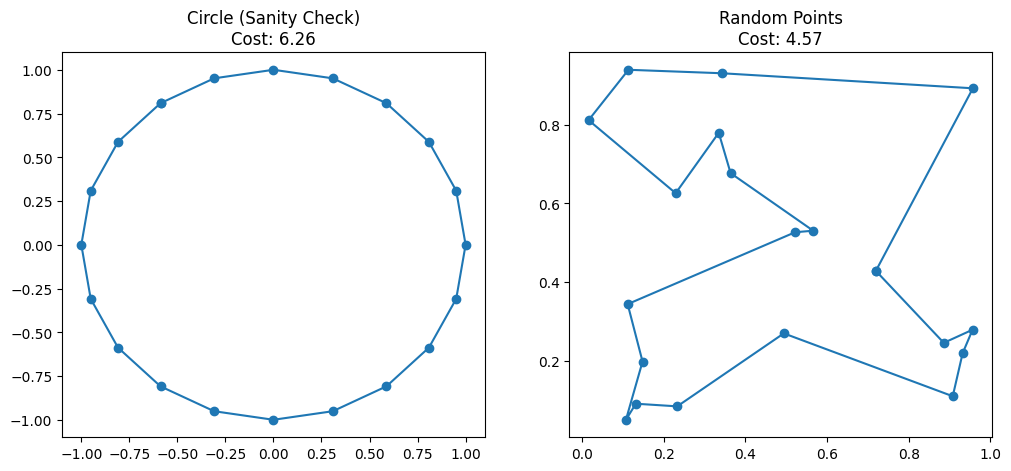

In [ ]:
def calculate_total_cost(route, points):
    #Euclidean distance of the route
    cost = 0
    n = len(route)
    for i in range(n):
        p1 = points[route[i]]
        p2 = points[route[(i + 1) % n]]  # Connect back to start
        cost += np.linalg.norm(p1 - p2)
    return cost

def get_proposal(route):
    #Generates proposals by swapping two randomly points
    new_route = route.copy()
    i, j = np.random.choice(len(route), 2, replace=False)
    # Swap two randomly selected points on the route 
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route

def simulated_annealing(points, iterations=10000):
    n = len(points)
    current_route = np.arange(n)
    np.random.shuffle(current_route)
    current_cost = calculate_total_cost(current_route, points)
    
    for k in range(iterations):
        new_route = get_proposal(current_route)
        new_cost = calculate_total_cost(new_route, points)
        
        # Apply cooling scheme 
        Tk = 1 / np.sqrt(1 + k) 
        
        # Acceptance rule
        delta = new_cost - current_cost
        if delta < 0 or np.random.rand() < np.exp(-delta / Tk):
            current_route = new_route
            current_cost = new_cost
            
    return current_route, current_cost


n_points = 20
# Sanity check using points on a circle 
theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)
points_circle = np.column_stack([np.cos(theta), np.sin(theta)])

# Random points in the plane 
points_random = np.random.rand(n_points, 2)


route_c, cost_c = simulated_annealing(points_circle)
route_r, cost_r = simulated_annealing(points_random)

# Plotting results 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, pts, route, title in zip([ax1, ax2], [points_circle, points_random], 
                                [route_c, route_r], ["Circle (Sanity Check)", "Random Points"]):
    ordered = pts[np.append(route, route[0])]
    ax.plot(ordered[:,0], ordered[:,1], 'o-')
    ax.set_title(f"{title}\nCost: {calculate_total_cost(route, pts):.2f}")

plt.show()

# Exercise 7 part 2

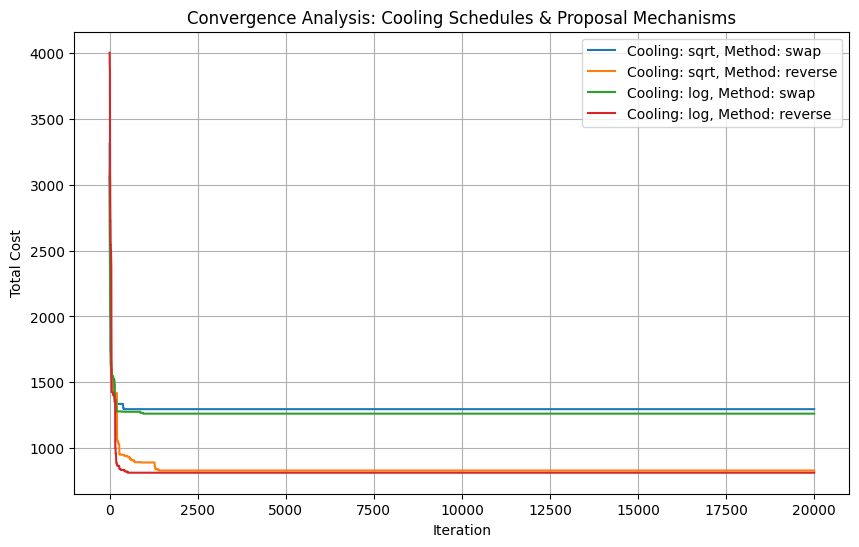

In [ ]:
cost_matrix = pd.read_csv('cost.csv', header=None).values

def calculate_total_cost(route, matrix):
    """Calculates the total cost of the route using the adjacency matrix."""
    cost = 0
    n = len(route)
    for i in range(n):
        u, v = route[i], route[(i + 1) % n]
        cost += matrix[u, v]
    return cost

def get_proposal(route, method='swap'):
    """Generates proposals by swapping two points or reversing a segment."""
    new_route = route.copy()
    i, j = sorted(np.random.choice(len(route), 2, replace=False))
    
    if method == 'swap':
        new_route[i], new_route[j] = new_route[j], new_route[i]
    elif method == 'reverse':
        new_route[i:j] = new_route[i:j][::-1]
    return new_route

def run_experiment(matrix, iterations=20000, cooling='sqrt', method='swap'):
    """Runs SA and tracks cost history for plotting."""
    n = matrix.shape[0]
    route = np.arange(n)
    np.random.shuffle(route)
    cost = calculate_total_cost(route, matrix)
    
    history = [cost]
    for k in range(iterations):
        new_route = get_proposal(route, method)
        new_cost = calculate_total_cost(new_route, matrix)
        
        # Cooling schedule
        Tk = 1 / np.sqrt(1 + k) if cooling == 'sqrt' else 1 / np.log(2 + k)
            
        delta = new_cost - cost
        if delta < 0 or np.random.rand() < np.exp(-delta / Tk):
            route = new_route
            cost = new_cost
        history.append(cost)
    return history

# Run experiments for all combinations
combinations = [
    ('sqrt', 'swap'), ('sqrt', 'reverse'),
    ('log', 'swap'), ('log', 'reverse')
]

plt.figure(figsize=(10, 6))
for cooling, method in combinations:
    history = run_experiment(cost_matrix, iterations=20000, cooling=cooling, method=method)
    plt.plot(history, label=f'Cooling: {cooling}, Method: {method}')

plt.title("Convergence Analysis: Cooling Schedules & Proposal Mechanisms")
plt.xlabel("Iteration")
plt.ylabel("Total Cost")
plt.legend()
plt.grid(True)
plt.show()